In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("results.csv")
df.columns

Index(['cache', 'sequence', 'run', 'oracle_cost', 'lru_cost', 'oracle_time',
       'lru_time'],
      dtype='object')

In [3]:
grouped = df.groupby(["p", "size"]).mean().reset_index().drop("i", axis=1)
grouped.to_csv("grouped.csv", index=False)

In [4]:
grouped

,p,size,classic,strassen,transposed
0,1,4,1.000000e-07,0.000001,0.000000e+00
1,1,8,3.000000e-07,0.000001,8.000000e-07
2,1,16,2.200000e-06,0.000004,2.200000e-06
3,1,32,1.910000e-05,0.000021,1.850000e-05
4,1,64,1.755000e-04,0.000182,1.701000e-04
...,...,...,...,...,...
83,128,256,8.668800e-03,0.020201,2.878500e-03
84,128,512,1.421740e-02,0.129151,7.953700e-03
85,128,1024,8.692440e-02,0.847714,2.167590e-02
86,128,2048,1.318108e+00,5.650723,1.528080e-01


In [40]:
pd.set_option('display.float_format', '{:.2E}'.format)
grouped.pivot(index="size", columns="p", values='transposed')

p,1,2,4,8,16,32,64,128
size,,,,,,,,
4,0.00E+00,4.00E-06,4.80E-06,4.70E-06,4.00E-06,4.00E-06,4.10E-06,4.10E-06
8,8.00E-07,7.00E-06,7.00E-06,7.00E-06,7.20E-06,7.00E-06,7.20E-06,7.00E-06
16,2.20E-06,1.60E-05,1.50E-05,1.50E-05,1.50E-05,1.59E-05,1.50E-05,1.50E-05
32,1.85E-05,4.83E-05,4.95E-05,4.76E-05,4.79E-05,4.84E-05,4.78E-05,4.95E-05
64,1.70E-04,2.50E-04,2.56E-04,2.51E-04,2.50E-04,2.51E-04,2.53E-04,2.51E-04
128,1.67E-03,1.94E-03,1.94E-03,1.94E-03,1.94E-03,1.94E-03,1.93E-03,1.94E-03
256,1.51E-02,8.43E-03,4.73E-03,2.74E-03,2.07E-03,2.30E-03,2.45E-03,2.88E-03
512,1.27E-01,6.76E-02,3.59E-02,1.96E-02,1.24E-02,8.63E-03,7.90E-03,7.95E-03
1024,1.04E+00,5.34E-01,2.76E-01,1.41E-01,7.53E-02,4.23E-02,2.77E-02,2.17E-02


In [5]:
classic_speedup = grouped.pivot(index="size", columns="p", values='classic').apply(lambda x: x[1] / x, axis=1).T
strassen_speedup = grouped.pivot(index="size", columns="p", values='strassen').apply(lambda x: x[1] / x, axis=1).T
transposed_speedup = grouped.pivot(index="size", columns="p", values='transposed').apply(lambda x: x[1] / x, axis=1).T

In [24]:
classic_speedup

size,4,8,16,32,64,128,256,512,1024,2048,4096
p,,,,,,,,,,,
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.014493,0.037975,0.154930,0.513441,0.748401,1.003734,2.034674,2.011500,1.898258,2.314045,2.455543
4,0.015385,0.040541,0.170543,0.503958,0.685279,0.993980,3.792205,3.529018,3.758515,4.893394,5.004260
8,0.010870,0.036145,0.173228,0.494819,0.740194,1.006260,6.648142,7.414344,7.493737,9.105207,10.529161
16,0.012346,0.039474,0.176000,0.512064,0.738326,0.991191,9.335426,13.063927,14.852521,17.057609,20.077339
32,0.013514,0.037500,0.165414,0.497396,0.748082,0.988707,10.524569,24.289112,29.587023,33.066330,39.749534
64,0.013333,0.036585,0.174603,0.503958,0.737395,0.992194,8.045612,36.286495,57.443631,63.265600,78.472253
128,0.015873,0.036145,0.177419,0.488491,0.740194,0.980632,4.751280,39.741999,94.824841,114.577996,134.611251


<Axes: xlabel='p'>

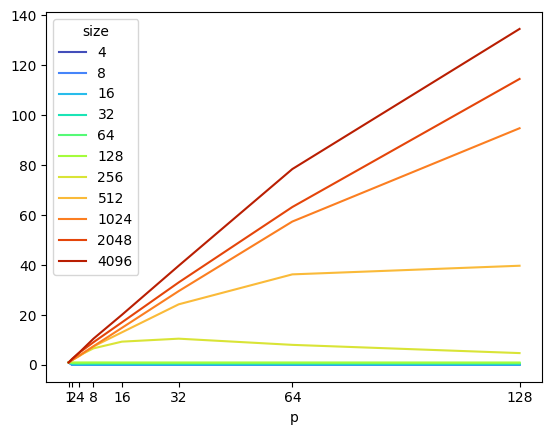

In [15]:
classic_speedup.plot(xticks=[1, 2, 4, 8, 16, 32, 64, 128], color=sns.color_palette("turbo", 11))

<Axes: xlabel='p'>

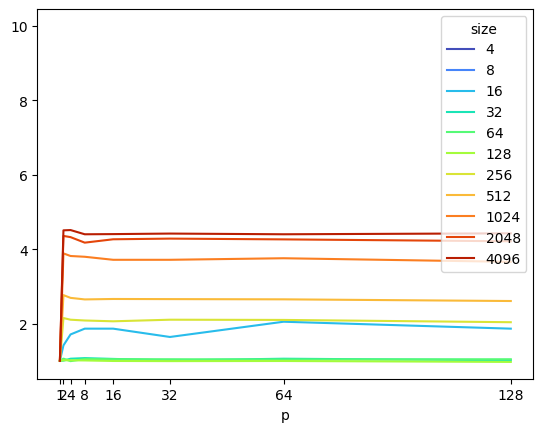

In [22]:
strassen_speedup.plot(xticks=[1, 2, 4, 8, 16, 32, 64, 128], color=sns.color_palette("turbo", 11))

<Axes: xlabel='p'>

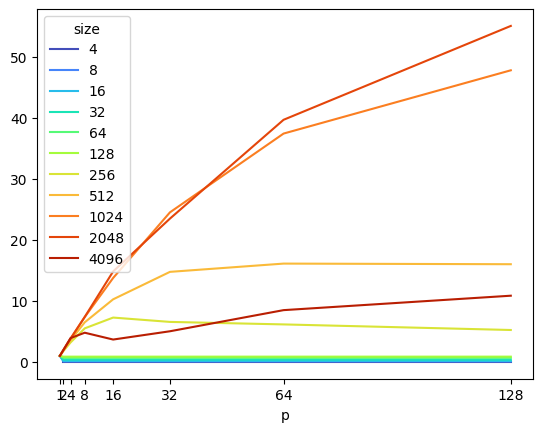

In [23]:
transposed_speedup.plot(xticks=[1, 2, 4, 8, 16, 32, 64, 128], color=sns.color_palette("turbo", 11))